In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from model_pipeline import get_train_test_splits
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV

In [17]:
df = pd.read_csv("../data/processed/train_ohe.csv")
df

,amt,city_pop,is_fraud,hour,age,distance_from_home,mean_amt,amt_std,is_new_user,distance_from_prev,...,state_WA,state_WI,state_WV,state_WY,week_day_Monday,week_day_Saturday,week_day_Sunday,week_day_Thursday,week_day_Tuesday,week_day_Wednesday
0,7.27,1645,0,12,33,127.606419,0.000000,0.000000,1,0.000000,...,0,0,0,1,0,0,0,0,1,0
1,52.94,1645,0,8,33,110.309077,7.270000,0.000000,0,224.769536,...,0,0,0,1,0,0,0,0,0,1
2,82.08,1645,0,8,33,21.787292,30.105000,32.293567,0,105.220587,...,0,0,0,1,0,0,0,0,0,1
3,34.79,1645,0,12,33,87.204338,47.430000,37.708144,0,88.152407,...,0,0,0,1,0,0,0,0,0,1
4,27.18,1645,0,13,33,74.213070,44.270000,31.430534,0,132.876960,...,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,60.47,532,0,21,64,78.492673,67.802931,157.357527,0,72.134080,...,0,0,0,0,0,1,0,0,0,0
1296671,74.29,532,0,0,64,55.400846,67.799363,157.319300,0,50.128303,...,0,0,0,0,0,0,1,0,0,0
1296672,246.56,532,0,2,64,115.674563,67.802519,157.281083,0,94.204046,...,0,0,0,0,0,0,1,0,0,0
1296673,2.62,532,0,8,64,60.513482,67.889421,157.292218,0,61.101300,...,0,0,0,0,0,0,1,0,0,0


In [ ]:
X_train, X_test, y_train, y_test = get_train_test_splits(df)

# TODO implement kfold and test on fraudTest.csv



NameError: name 'get_train_test_splits' is not defined

In [19]:
print(X_train.shape, y_train.shape)

(1037340, 83) (1037340,)


In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42
) #TODO implement gridsearch
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["sqrt", "log2"],
    "model__class_weight": ["balanced", "balanced_subsample"]
}

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=30,
    scoring="average_precision",
    cv=3,
    random_state=4,
    n_jobs=-1,
    verbose=3
)




search.fit(X_train, y_train)
best_model = search.best_estimator_

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

# TODO Make model two stage

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.98      0.73      0.83      1501

    accuracy                           1.00    259335
   macro avg       0.99      0.86      0.92    259335
weighted avg       1.00      1.00      1.00    259335



roc_auc: 0.993237942470326, pr_auc: 0.9246769274524205, best_recall: 0.8481012658227848


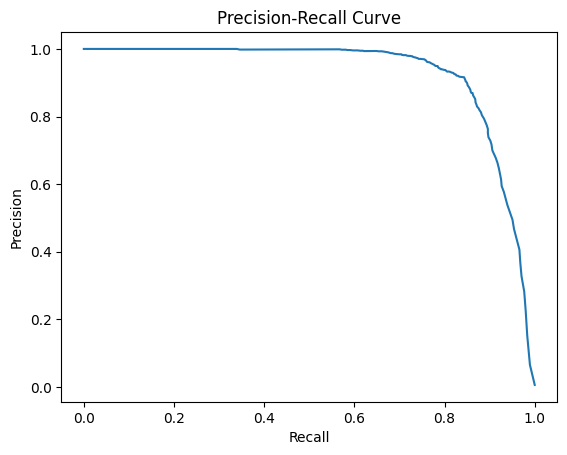

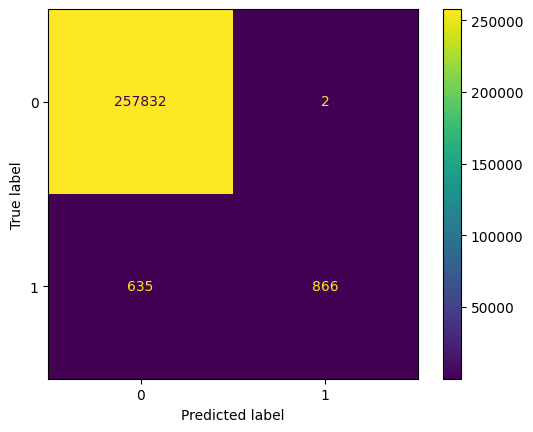